# FASE 1: ENTENDIMIENTO DEL NEGOCIO
> Traducir los objetivos y requisitos del negocio en una definición de problema de minería de datos. En esta etapa inicial, se busca comprender profundamente qué es lo que el cliente o la organización realmente quiere lograr, estableciendo metas claras, evaluando la situación actual (recursos y limitaciones) y diseñando un plan preliminar de proyecto que alinee los esfuerzos técnicos con los resultados estratégicos esperados


# Analisis Predictivo Industrial
##Fase 1: Metodología CRISP-DM - Entendimiento del negocio

## **Contexto de la Operación**
La empresa "Industrial Tech Solutions" opera fresadoras CNC de alta precisión. Actualmente, la planta utiliza un modelo de mantenimiento preventivo basado en tiempo (se cambia la herramienta cada X horas) y mantenimiento correctivo (se reacciona cuando la máquina falla).

A pesar de cumplir con los cronogramas de mantenimiento, la planta sigue experimentando:

* Paros de línea no programados que detienen la producción por horas.

* Lotes de productos defectuosos debido a variaciones térmicas y de torque no detectadas a tiempo.

## **Definición del Problema (El "Asesino Silencioso")**

El problema principal es la Variabilidad No Detectada. Los ingenieros de planta no pueden monitorear manualmente la relación entre la temperatura del aire, la velocidad de rotación y el desgaste de la herramienta en tiempo real.

**Consecuencia económica:**

Costo de No Calidad: Se estima en un 18% de las ventas anuales debido a scrap y re-trabajos.

Ineficiencia de Datos: Se generan miles de registros por segundo a través de sensores IoT, pero menos del 5% se analizan (Dark Data).

## **Objetivo del Proyecto (Analítica Prescriptiva)**

Utilizar el dataset AI4I 2020 para desarrollar un modelo de Machine Learning capaz de:

1. Predecir fallos prematuros con una ventana de tiempo suficiente para intervenir.

2. Identificar las variables con mayor correlación de incidencia de fallo de la maquina

3. Cuantificar el impacto de establecer un modelo de mantenimiento predictivo en la planta

# Fase 2: Entendimiento de los datos
> Entender los **datos disponibles** para identificar su **calidad** y utilidad real antes de iniciar cualquier análisis profundo. En esta etapa se realiza la recolección inicial, se **describen las variables**, se exploran sus propiedades estadísticas y se verifica si existen problemas de integridad (como valores nulos o incoherencias); todo esto con el fin de confirmar que la información disponible es suficiente y adecuada para resolver los objetivos de negocio definidos en la fase anterior.


In [ ]:
#Importamos librerias base para manejo de datos, matrices y visualizaciones
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Librerias estadisticas
from scipy import stats


#Librerias para modelar y evualar
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import shap

In [ ]:
# Cargamos el dataset real de mantenimiento predictivo
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00601/ai4i2020.csv"
df = pd.read_csv(url)
df

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0


In [ ]:
#Renombramos las columnas para un mejor entendimiento del problema

nuevos_nombres = {
    'UDI': 'ID_Unico',
    'Product ID': 'ID_Producto',
    'Type': 'Tipo_Material',
    'Air temperature [K]': 'Temp_Aire_K',
    'Process temperature [K]': 'Temp_Proceso_K',
    'Rotational speed [rpm]': 'Velocidad_Rotacion_RPM',
    'Torque [Nm]': 'Torque_Nm',
    'Tool wear [min]': 'Desgaste_Herramienta_min',
    'Machine failure': 'Falla_Maquina',
    'TWF': 'Falla_Desgaste_Herramienta',
    'HDF': 'Falla_Disipacion_Calor',
    'PWF': 'Falla_Potencia',
    'OSF': 'Falla_Sobreesfuerzo',
    'RNF': 'Falla_Aleatoria'
}

df.rename(columns=nuevos_nombres, inplace=True)
df

,ID_Unico,ID_Producto,Tipo_Material,Temp_Aire_K,Temp_Proceso_K,Velocidad_Rotacion_RPM,Torque_Nm,Desgaste_Herramienta_min,Falla_Maquina,Falla_Desgaste_Herramienta,Falla_Disipacion_Calor,Falla_Potencia,Falla_Sobreesfuerzo,Falla_Aleatoria
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0


## Significado de las variables
| Nombre Original | Nombre en español | Descripción tecnica |
| :---: | :---: | :---: |
| Type (L, M, H) | Tipo_Material | Dureza: Low (50%), Medium (30%), High (20%). |
| Air temperature | Temp_Aire_K | Temperatura ambiente generada por el sistema de refrigeración. |
| Process temperature | Temp_Proceso_K | Temperatura generada por la fricción durante el proceso de fresado. |
| Rotational speed | Velocidad_RPM | Velocidad de giro del cabezal (crucial para detectar vibraciones). |
| Torque | Torque_Nm | Fuerza de torsión aplicada (si sube mucho, la herramienta se rompe). |
| Tool wear | Desgaste_min | Minutos de uso acumulados de la herramienta de corte. |
| Machine failure | Falla_General | Indicador binario (0 o 1) si ocurrió cualquier tipo de fallo. |
|  |  |  |



In [ ]:
#Verificamos valores nulos
df.isnull().sum()

,0
ID_Unico,0
ID_Producto,0
Tipo_Material,0
Temp_Aire_K,0
Temp_Proceso_K,0
Velocidad_Rotacion_RPM,0
Torque_Nm,0
Desgaste_Herramienta_min,0
Falla_Maquina,0
Falla_Desgaste_Herramienta,0


In [ ]:
#verificmos tipos de datos
df.dtypes

,0
ID_Unico,int64
ID_Producto,object
Tipo_Material,object
Temp_Aire_K,float64
Temp_Proceso_K,float64
Velocidad_Rotacion_RPM,int64
Torque_Nm,float64
Desgaste_Herramienta_min,int64
Falla_Maquina,int64
Falla_Desgaste_Herramienta,int64


In [ ]:
#Prporcion de Fallas
df['Falla_Maquina'].value_counts(normalize=True)*100

,proportion
Falla_Maquina,
0,96.61
1,3.39


In [ ]:

#Analisis descriptivo inicial

cols_descriptivas = ['Temp_Aire_K', 'Temp_Proceso_K', 'Velocidad_Rotacion_RPM', 'Torque_Nm', 'Desgaste_Herramienta_min','Falla_Maquina']
df[cols_descriptivas].describe().T

,count,mean,std,min,25%,50%,75%,max
Temp_Aire_K,10000.0,300.00493,2.000259,295.3,298.3,300.1,301.5,304.5
Temp_Proceso_K,10000.0,310.00556,1.483734,305.7,308.8,310.1,311.1,313.8
Velocidad_Rotacion_RPM,10000.0,1538.77610,179.284096,1168.0,1423.0,1503.0,1612.0,2886.0
Torque_Nm,10000.0,39.98691,9.968934,3.8,33.2,40.1,46.8,76.6
Desgaste_Herramienta_min,10000.0,107.95100,63.654147,0.0,53.0,108.0,162.0,253.0
Falla_Maquina,10000.0,0.03390,0.180981,0.0,0.0,0.0,0.0,1.0


In [ ]:
# Calculo del coeficiente de variación

cols_cv = ['Temp_Aire_K', 'Temp_Proceso_K', 'Velocidad_Rotacion_RPM', 'Torque_Nm', 'Desgaste_Herramienta_min']


resultados_cv = []

for cols in cols_cv:
  cv =(df[cols].std()/df[cols].mean())*100

  resultados_cv.append({'variable': cols,
                        'std':df[cols].std(),
                        'mean':df[cols].mean(),
                        'cv_%': round(cv, 2)

                        })

df_cv = pd.DataFrame(resultados_cv).sort_values(by='cv_%', ascending=False)
df_cv


,variable,std,mean,cv_%
4,Desgaste_Herramienta_min,63.654147,107.95100,58.97
3,Torque_Nm,9.968934,39.98691,24.93
2,Velocidad_Rotacion_RPM,179.284096,1538.77610,11.65
0,Temp_Aire_K,2.000259,300.00493,0.67
1,Temp_Proceso_K,1.483734,310.00556,0.48


## Hallazgos iniciales

---
### Análisis térmico
* La temparatura del ambiente generada por el sistema de refrigeración y la temperatura generada por el proces de fresado mantienen valores promedio aproximados de 300 y 310 K aproximadamente con una variabilidad baja de aproximadamente de 2 y 1.48 K aproximadamente lo que se considera baja. Los Valores promedio son similiares a los valores medios lo que es indicativo ausnecia de valores atipicos

### Velocidad
La velocidad de rotación presenta un valor promedio de 1538 RPM con una desviación estandar 179 RPm lo que suele ser indicio de una alta variabilidad auque puede estar explicada por la dureza del material(H, M, L)

### Torque
En cuanto a la Fuerza ejercida se evdencia un valor promedio de 39.9 Nm lo que comparado con la desviación estandar de 9.96 estaría dando indicios de alata variabilidad; Adicional si observamos el valor maximo (76) es casi el doble del promedio

NOTA: un torque de 76 Nm con una velocidad baja es la receta perfecta para una Falla por Sobreesfuerzo

### Desgaste de la herramienta
El desgaste de la herramienta nuestra un uso promedio de 107.9 minutos con una desviación estandar de 63 minutos

**Pregunta de Negocio: ¿A partir de qué minuto la variabilidad del torque se vuelve inmanejable?**




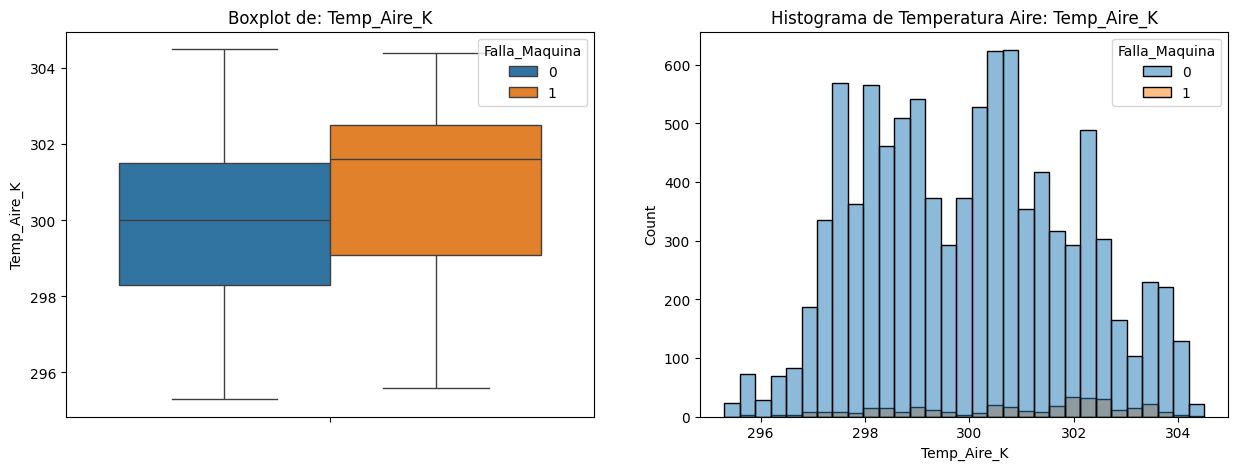

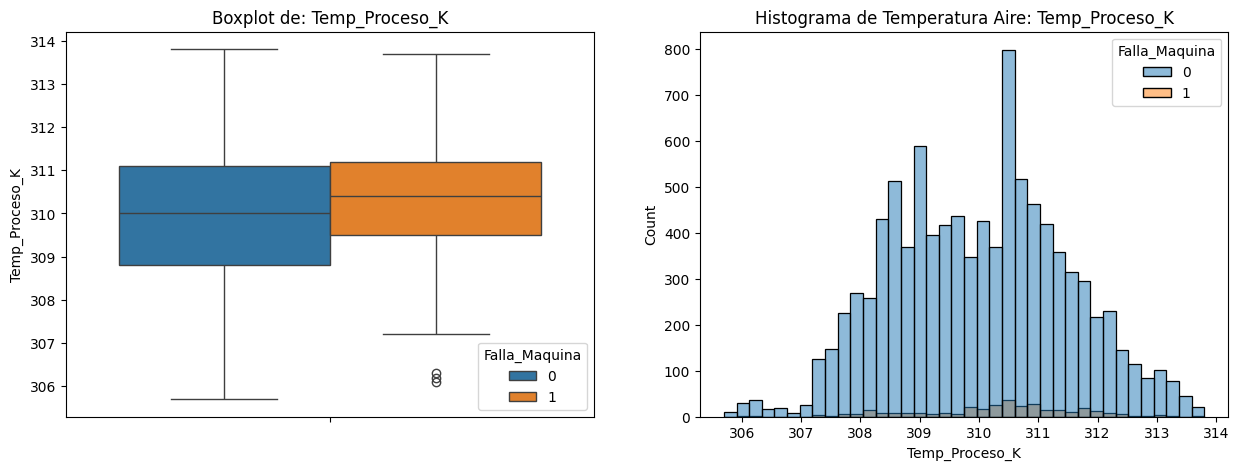

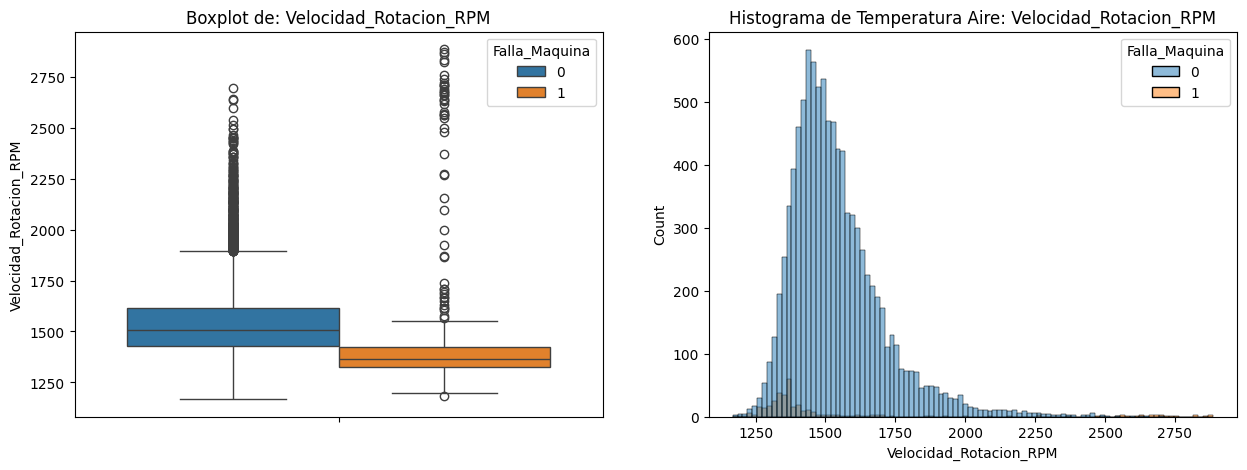

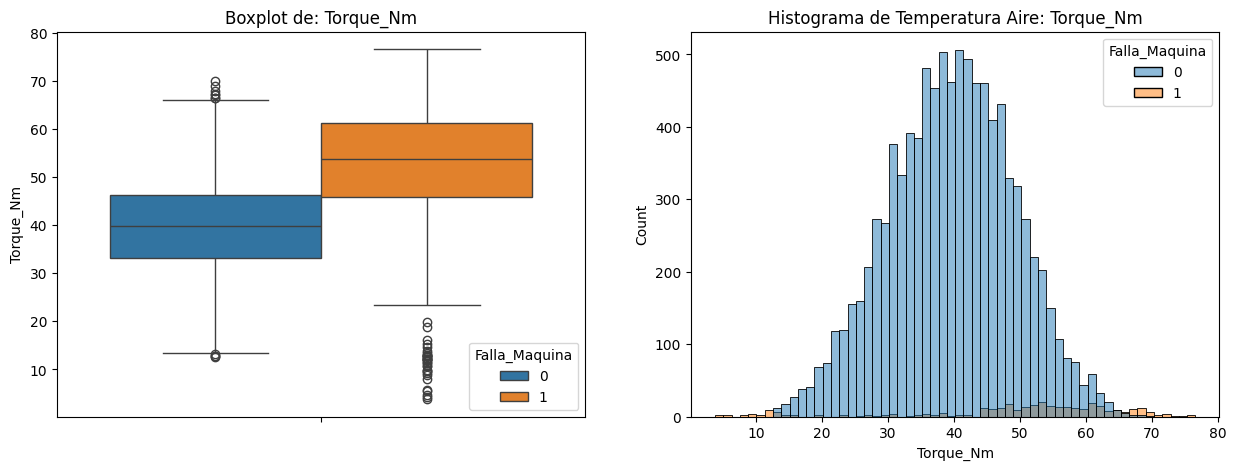

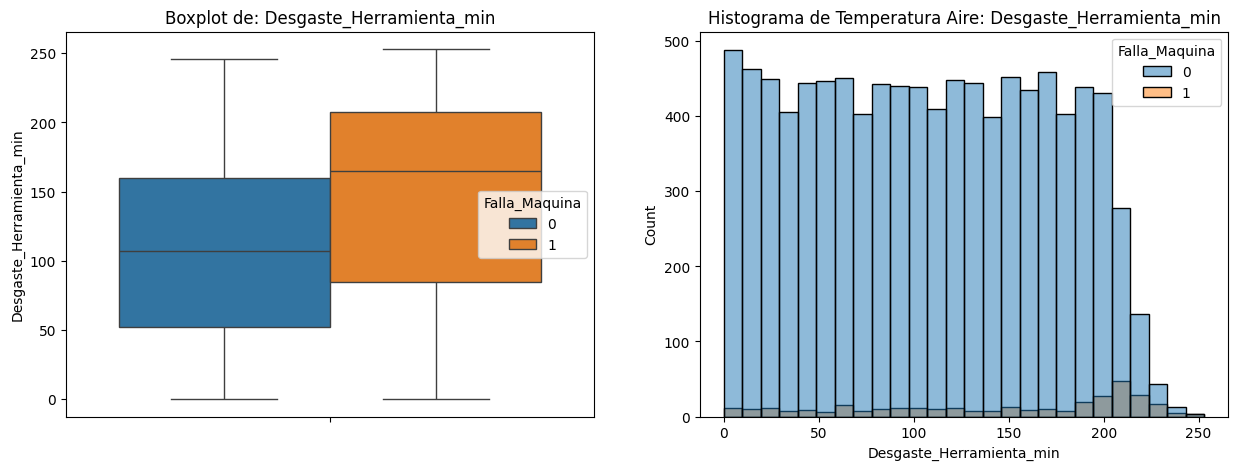

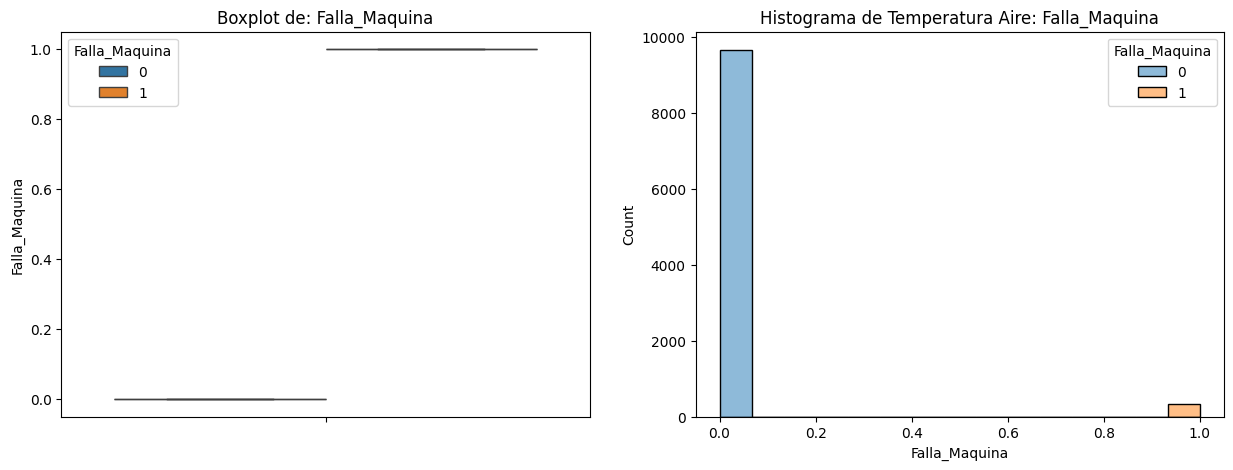

In [ ]:
#Diagramas de caja
#definimos las regillas


for cols in cols_descriptivas:

  fig, ax = plt.subplots(1,2, figsize=(15,5))

  #Boxplots
  sns.boxplot(data=df,
              y=cols,
              hue="Falla_Maquina",
              ax=ax[0])
  ax[0].set_title(f"Boxplot de: {cols}")

  #Histogramas
  sns.histplot(data=df,
              x=cols,
              ax=ax[1],
              hue="Falla_Maquina")
  ax[1].set_title(f"Histograma de Temperatura Aire: {cols}")

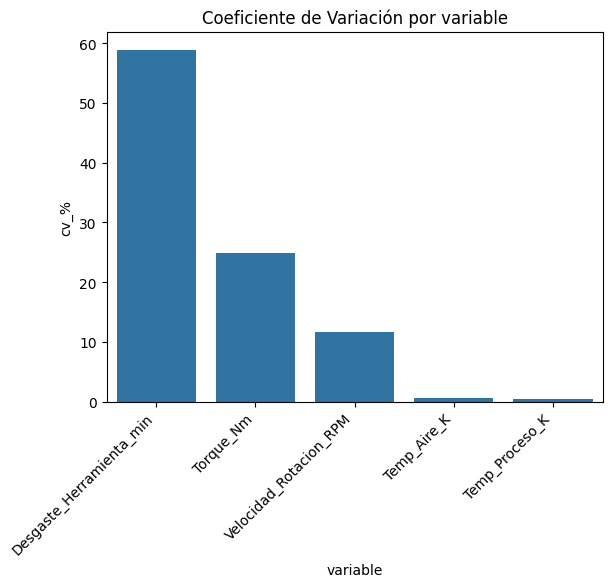

In [ ]:
sns.barplot(df_cv,
            x='variable',
            y='cv_%')
plt.title('Coeficiente de Variación por variable')
plt.xticks(rotation=45, ha='right')
plt.show()

In [ ]:
df.columns

Index(['ID_Unico', 'ID_Producto', 'Tipo_Material', 'Temp_Aire_K',
       'Temp_Proceso_K', 'Velocidad_Rotacion_RPM', 'Torque_Nm',
       'Desgaste_Herramienta_min', 'Falla_Maquina',
       'Falla_Desgaste_Herramienta', 'Falla_Disipacion_Calor',
       'Falla_Potencia', 'Falla_Sobreesfuerzo', 'Falla_Aleatoria'],
      dtype='object')

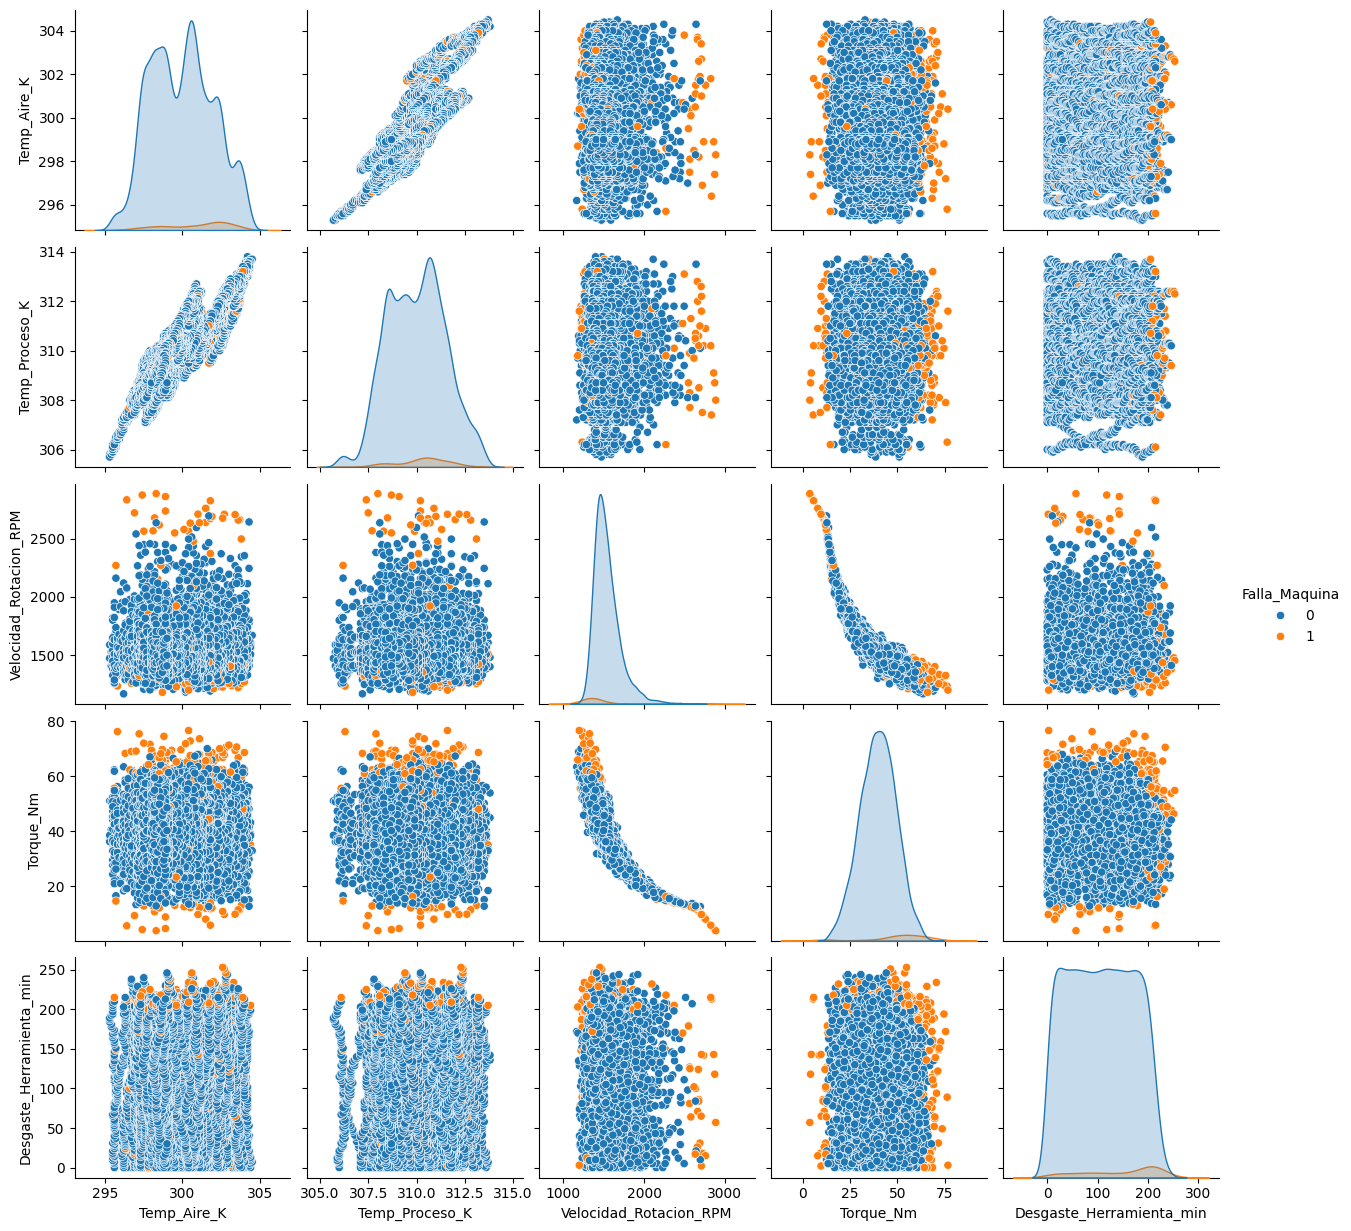

In [ ]:
sns.pairplot(data = df[cols_descriptivas],
             hue = "Falla_Maquina")

In [ ]:
#Analizamos si la variabilidad depende del tipo de material
df_materaial = df.groupby('Tipo_Material')[['Velocidad_Rotacion_RPM', 'Torque_Nm']].agg(['mean', 'std']).T
df_materaial

Tipo_Material                          H            L            M
Velocidad_Rotacion_RPM mean  1538.147557  1539.469167  1537.598932
                       std    173.133428   180.428518   179.059828
Torque_Nm              mean    39.838285    39.996600    40.017251
                       std      9.642339    10.012335     9.992153

* La desviación estandar es casi identica en todos los materiales. Lo que sigifica que la variabilidad no esta atribuida al tipo de material sino a fallas del sistema o de las maquinas. Se debe mirar a que se atribuye la causa, sensor, motor o desgaste.

<Axes: xlabel='Velocidad_Rotacion_RPM', ylabel='Torque_Nm'>

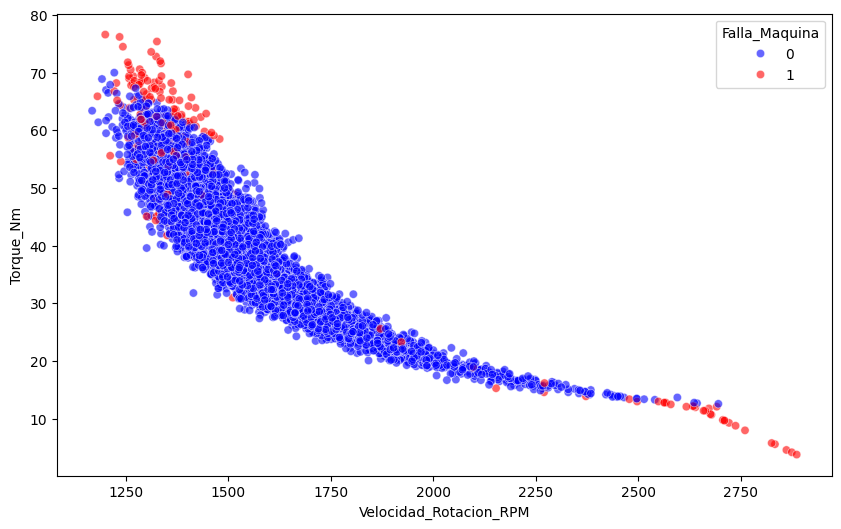

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df,
                x = 'Velocidad_Rotacion_RPM',
                y='Torque_Nm',
                hue='Falla_Maquina',alpha=0.6,
                palette={0: 'blue', 1: 'red'}
                )


> NOTA: Por regla general se supone que a mayor velocidad menor Fuerza de toque se debe aplicar.

Los valores superiores a la izquierda indicacan efectivamente fallos por sobre esfuerzo y potencia, es decir, se está aplicando una fuerza excesiva a una velocidad muy baja

La falla no depende de una sola variable, sino de cuando se rompe la relación de -0.88 entre torque y velocidad. El modelo de IA será capaz de detectar cuando ese balance perfecto se pierde

In [ ]:
# Comparativa de Correlaciones
pearson = df['Velocidad_Rotacion_RPM'].corr(df['Torque_Nm'], method='pearson')
spearman = df['Velocidad_Rotacion_RPM'].corr(df['Torque_Nm'], method='spearman')

print(f"Correlación Lineal (Pearson): {pearson:.4f}")
print(f"Correlación de Rango (Spearman): {spearman:.4f}")

Correlación Lineal (Pearson): -0.8750
Correlación de Rango (Spearman): -0.9165


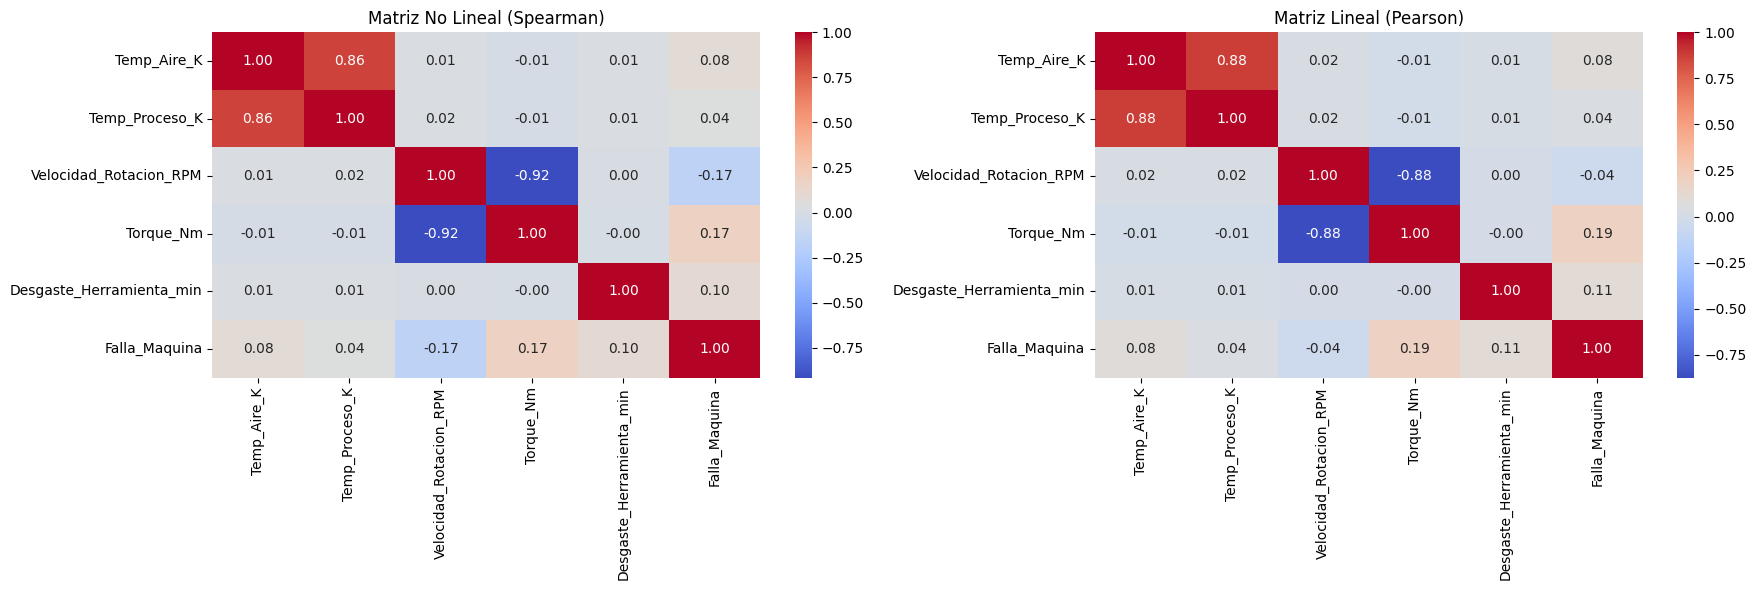

In [ ]:

cols_corr = ['Temp_Aire_K', 'Temp_Proceso_K', 'Velocidad_Rotacion_RPM', 'Torque_Nm', 'Desgaste_Herramienta_min', 'Falla_Maquina']

# 1. Calculamos ambas matrices por separado
corr_spearman = df[cols_corr].corr(method='spearman')
corr_pearson = df[cols_corr].corr(method='pearson') # Pearson es el estándar lineal

fig, ax = plt.subplots(1, 2, figsize=(18, 6))

# Gráfica 1: Spearman (No Lineal)
sns.heatmap(corr_spearman, annot=True, cmap='coolwarm', fmt=".2f", ax=ax[0])
ax[0].set_title("Matriz No Lineal (Spearman)")

# Gráfica 2: Pearson (Lineal)
sns.heatmap(corr_pearson, annot=True, cmap='coolwarm', fmt=".2f", ax=ax[1])
ax[1].set_title("Matriz Lineal (Pearson)")

plt.tight_layout()
plt.show()

* Existe una relación no lineal clara. A medida que la velocidad baja (RPM bajas), el riesgo de falla aumenta (porque suele ir amarrado a torques excesivos).

* Torque vs Falla (0.17): Se mantiene como un predictor positivo importante.

* Desgaste vs Falla (0.10): Aunque parece bajo, es una correlación "limpia". Nos dice que el tiempo de uso de la herramienta sí pesa, pero no es el único factor.

## FASE 3: Preparación de los datos
> En esta etapa, se seleccionan las tablas, registros y atributos necesarios, se limpian los datos para tratar errores o valores nulos detectados en la fase anterior, y se generan nuevas variables (ingeniería de atributos) que puedan aportar valor.


### Ingeniera de Caracteristicas

In [ ]:
#1. Calculo de la potencia (Relación fisica entre Toque y velocidad)
#Usamos contante de conversión simle (Vel * Torque) / 9.5488

df['Potencia_W'] = (df['Velocidad_Rotacion_RPM'] * df['Torque_Nm']) / 9.5488

#2. Diferencial de temperatura (Esfuerzo termico)
df['Dif_temperatura_K'] = df['Temp_Proceso_K'] - df['Temp_Aire_K']

#3 Factor de desgaste torque (que tanto sufre la herramienta)
df['Esfuerzo_desgaste'] = df['Torque_Nm'] * df['Desgaste_Herramienta_min']

print("Variables Creadas Exitosamente")

Variables Creadas Exitosamente


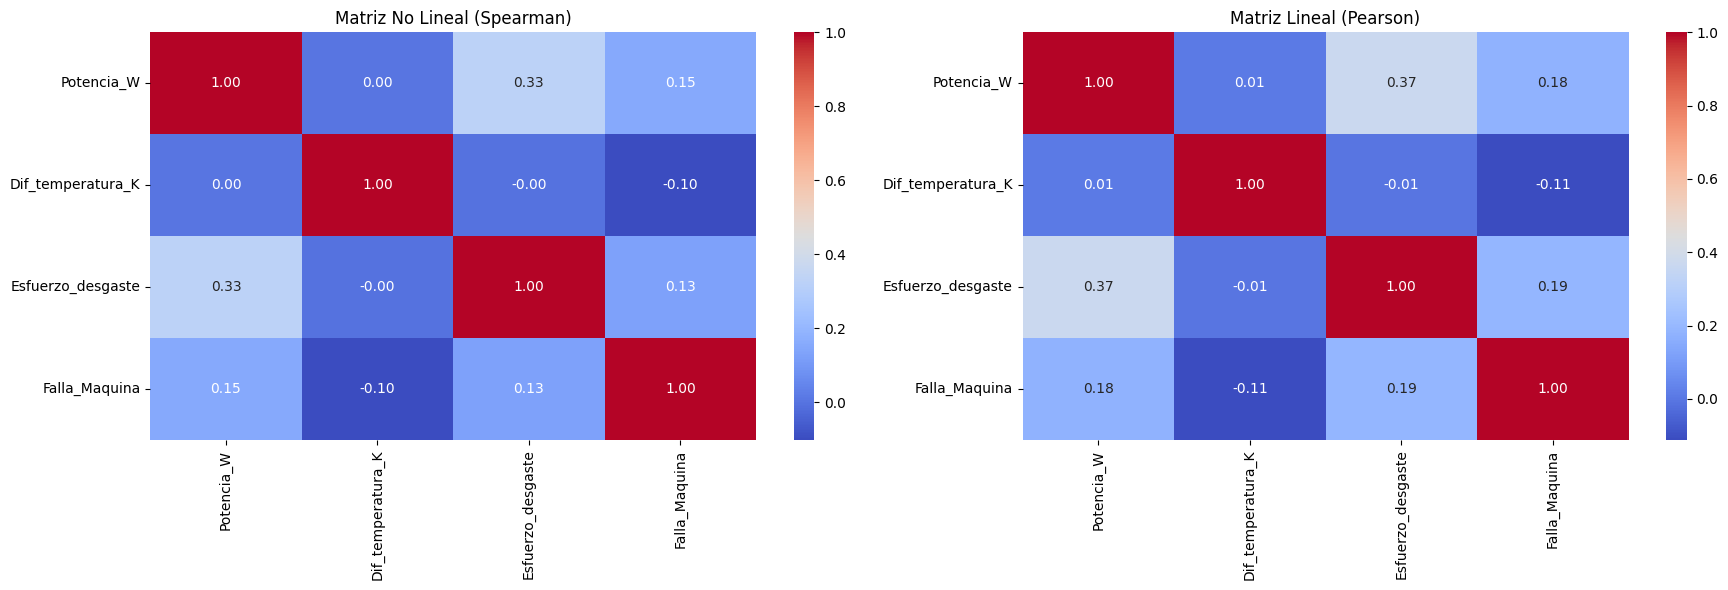

In [ ]:
#Calculamos un nuevo df con la variable objetivo y las predictoras nuevas
df_nuevo = df[[
            'Potencia_W',
            'Dif_temperatura_K',
            'Esfuerzo_desgaste',
            'Falla_Maquina'
            ]]

# 1. Calculamos ambas matrices por separado
corr_spearman = df_nuevo.corr(method='spearman')
corr_pearson = df_nuevo.corr(method='pearson') # Pearson es el estándar lineal

fig, ax = plt.subplots(1, 2, figsize=(18, 6))

# Gráfica 1: Spearman (No Lineal)
sns.heatmap(corr_spearman, annot=True, cmap='coolwarm', fmt=".2f", ax=ax[0])
ax[0].set_title("Matriz No Lineal (Spearman)")

# Gráfica 2: Pearson (Lineal)
sns.heatmap(corr_pearson, annot=True, cmap='coolwarm', fmt=".2f", ax=ax[1])
ax[1].set_title("Matriz Lineal (Pearson)")

plt.tight_layout()
plt.show()

> Un Ingeniero sin contexto vería mis nuevas variables y diría: 'Usemos un modelo lineal, es más simple y Pearson lo entiende'. Pero como Ingenieros, sabemos que los procesos físicos no son líneas rectas; son zonas de operación. La falla no avisa con una pendiente suave; la falla es un salto cuántico de 'operando' a 'roto'. Por eso, elegimos modelos no lineales (como árboles de decisión), porque ellos sí pueden mapear esos umbrales de seguridad que definimos en los manuales de ingeniería.

No se incluyeron las variables orignales de temperatura porque al combinar ambas en una, el modelo tiene un árbol de decisión más corto y eficiente. En lugar de preguntar: "¿Está el aire caliente? ¿Y está el proceso más caliente?", solo pregunta: "¿Es el diferencial peligroso?

## FASE 3 y 4: Modelado y Evaluación
> La Fase 4 (Modelado) es el núcleo técnico del proyecto. En esta etapa, se seleccionan y aplican las técnicas de minería de datos o algoritmos de Machine Learning (como árboles de decisión, redes neuronales o regresiones) sobre los datos que preparaste en la fase anterior.

>La Fase 5 (Evaluación) es el momento de la verdad. A diferencia de la fase anterior (donde medías si el modelo era técnicamente preciso), aquí el objetivo es determinar si el modelo realmente cumple con los objetivos de negocio que definiste en la Fase 1.

¿Este modelo me ayuda a reducir los costos de mantenimiento?" o "¿Predice los fallos con suficiente antelación para que la empresa actúe?".

In [ ]:


# 1. Seleccionamos las variables (Tus features de ingeniería + las clave)
features = ['Potencia_W',
            'Dif_temperatura_K',
            'Esfuerzo_desgaste',
            'Velocidad_Rotacion_RPM',
            'Torque_Nm',
            'Desgaste_Herramienta_min']

X = df[features]
y = df['Falla_Maquina']

# 2. División Entrenamiento/Prueba
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)

# 3. Entrenamos el Bosque Aleatorio con peso balanceado para el desbalance
modelo = RandomForestClassifier(n_estimators=100,
                                class_weight='balanced',
                                random_state=42)

modelo.fit(X_train,
           y_train)

# 4. Predicciones
y_pred = modelo.predict(X_test)

# 5. Evaluación
print(classification_report(y_test,
                            y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.90      0.78      0.83        68

    accuracy                           0.99      2000
   macro avg       0.95      0.89      0.91      2000
weighted avg       0.99      0.99      0.99      2000



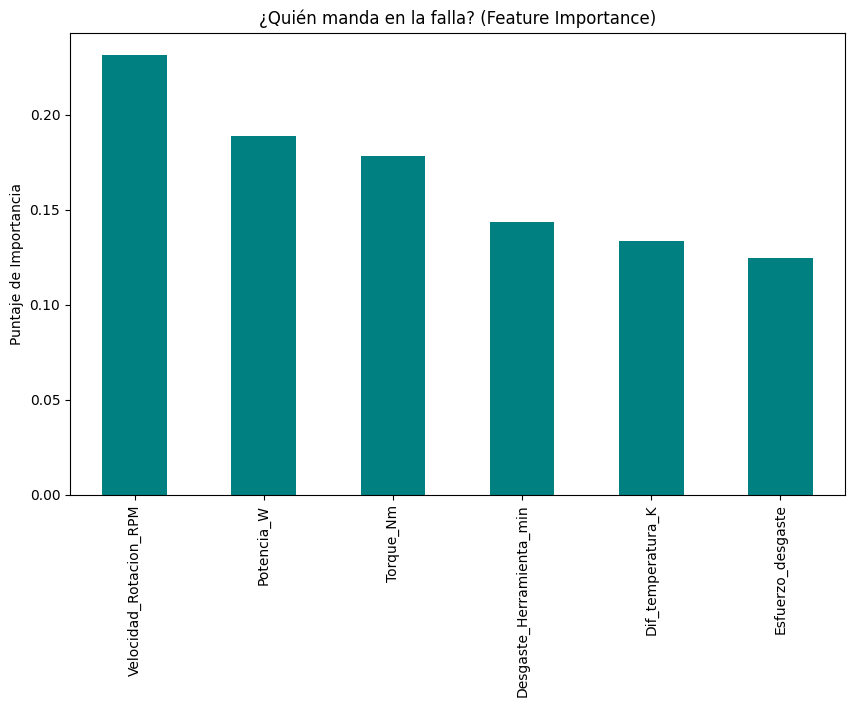

In [ ]:

importances = pd.Series(modelo.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(10,6))
importances.plot(kind='bar', color='teal')
plt.title("¿Quién manda en la falla? (Feature Importance)")
plt.ylabel("Puntaje de Importancia")
plt.show()

Incluimos las variables originales porque son los 'ojos' del modelo (lo que ve el sensor en tiempo real). Pero incluimos las variables creadas porque son el 'cerebro' (lo que el ingeniero deduce de esos datos). Al darle ambas al algoritmo, permitimos que identifique desde un accidente repentino hasta una degradación lenta por fatiga. No estamos duplicando datos, estamos dándole contexto físico a la estadística.

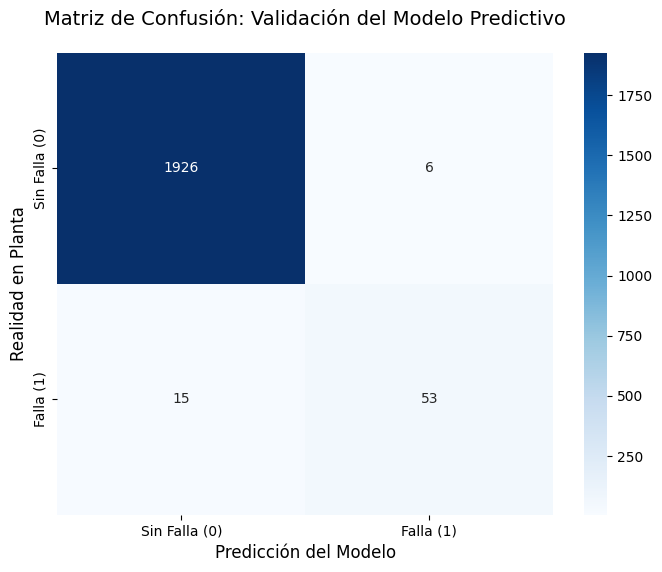

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Generar la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# 2. Configurar la visualización
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sin Falla (0)', 'Falla (1)'],
            yticklabels=['Sin Falla (0)', 'Falla (1)'])

# 3. Etiquetas y estética
plt.title('Matriz de Confusión: Validación del Modelo Predictivo', fontsize=14, pad=20)
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.ylabel('Realidad en Planta', fontsize=12)

# Añadir una línea divisoria para resaltar el cuadrante de éxito
plt.show()

## Analisis de evaluación del modelo

Dado el desbalance crítico de clases (comportamiento intrínseco en entornos industriales), hemos desplazado el foco de evaluación de la Exactitud (Accuracy) hacia la Sensibilidad (Recall). Mientras que la exactitud global puede ser engañosa debido al alto volumen de casos normales, un Recall del 78% en la clase 'Falla' nos da una medida directa del impacto operativo: estamos detectando casi 8 de cada 10 paradas no programadas. Este nivel de detección, combinado con una Precisión del 90%, garantiza que el modelo no solo es preventivo, sino también altamente confiable para la toma de decisiones en planta

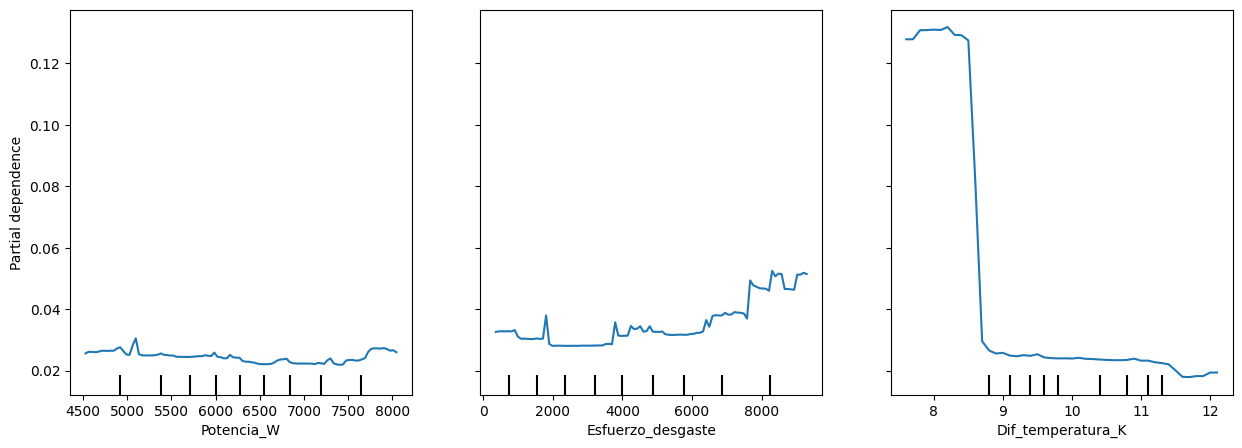

In [ ]:
from sklearn.inspection import PartialDependenceDisplay

# Elegimos las 3 variables más importantes para ver sus umbrales
fig, ax = plt.subplots(figsize=(15, 5))
PartialDependenceDisplay.from_estimator(modelo, X_train,
                                        features=['Potencia_W', 'Esfuerzo_desgaste', 'Dif_temperatura_K'],
                                        ax=ax)
plt.show()

In [ ]:
from sklearn.tree import export_text

# Extraemos un solo árbol del bosque (por ejemplo, el primero)
arbol_ejemplo = modelo.estimators_[0]

# Generamos las reglas en texto
reglas = export_text(arbol_ejemplo, feature_names=features)
print(reglas[:500]) # Imprimimos los primeros niveles

|--- Velocidad_Rotacion_RPM <= 1386.50
|   |--- Potencia_W <= 8529.93
|   |   |--- Potencia_W <= 8427.47
|   |   |   |--- Dif_temperatura_K <= 8.65
|   |   |   |   |--- Dif_temperatura_K <= 8.55
|   |   |   |   |   |--- Desgaste_Herramienta_min <= 5.50
|   |   |   |   |   |   |--- class: 0.0
|   |   |   |   |   |--- Desgaste_Herramienta_min >  5.50
|   |   |   |   |   |   |--- Velocidad_Rotacion_RPM <= 1379.50
|   |   |   |   |   |   |   |--- class: 1.0
|   |   |   |   |   |   |--- Velocidad_Rot


## Supuesto teorico del Impacto Económico (ROI)

1. Definición de la "Falla Catastrófica" (Sin Modelo)Si la máquina rompe por fatiga total (Falla no detectada):

* Repuesto de urgencia: $2,500 USD (Rodamientos, motor o husillo).

* Mano de obra especializada (Urgencia): $500 USD.

* Parada de línea (6 horas): $1,200 USD/hora x 6h = $7,200 USD.

> Total Falla Reactiva: $10,200 USD.

2. Definición del "Mantenimiento Predictivo" (Con tu Modelo)
Si el modelo avisa (Falla detectada con 78% de éxito):

* Repuesto programado: $1,500 USD (Se compra sin urgencia, mejor precio).

* Mano de obra interna: $200 USD (En turno normal).

* Parada programada (2 horas): Se hace en cambio de turno o fin de semana. Costo de oportunidad: $0 USD.

> Total Mantenimiento Predictivo: $1,700 USD.


###  Análisis de Impacto Económico (ROI)

| Escenario | Cálculo | Costo Total Anual |
|---|---|---|
| Escenario A: Sin Modelo | 100 fallas × 10,200 | 1,020,000 USD |
| Escenario B: Con tu Modelo | (78 fallas × 1,700) + (22 fallas × 10,200) | 357,000 USD |

**Ahorro Total Estimado: $663,000 USD** (Reducción del 65% en costos de mantenimiento).

*Nota: Las 22 fallas representan el 22% de riesgo residual no capturado por el Recall del modelo.*


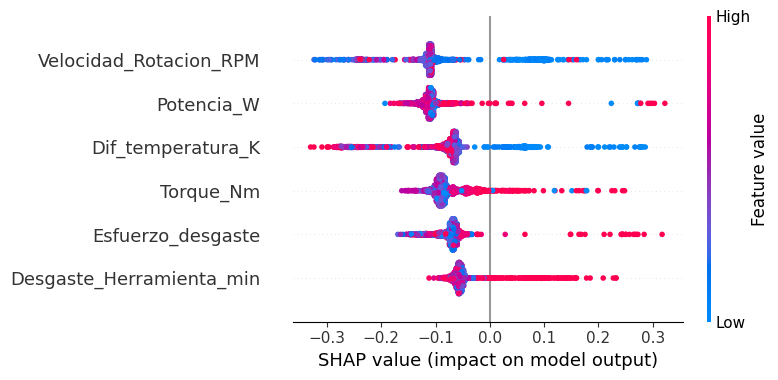

In [ ]:
# 1. Creamos el explicador
explainer = shap.TreeExplainer(modelo)

# 2. Calculamos los valores SHAP
# Usamos check_additivity=False por si hay pequeñas discrepancias numéricas
shap_values = explainer.shap_values(X_test, check_additivity=False)

# 3. EL TRUCO PARA EL ERROR DE SHAPE:
# Si shap_values es una lista, tomamos la posición [1] (clase positiva/Fallo)
# Si es un array 3D, tomamos la rebanada correspondiente
if isinstance(shap_values, list):
    # Caso: Lista de matrices (común en sklearn antiguo/específico)
    correct_shap_values = shap_values[1]
elif len(shap_values.shape) == 3:
    # Caso: Array 3D [muestras, características, clases]
    correct_shap_values = shap_values[:, :, 1]
else:
    # Caso: Ya es una matriz 2D
    correct_shap_values = shap_values

# 4. Graficar usando explícitamente los nombres de las columnas
shap.summary_plot(correct_shap_values, X_test, feature_names=X_test.columns)